# Market Pattern CNN

Predicts stock market movement (**Up / Down / Sideways**) from candlestick chart images using transfer learning.

### Models
| Model | Type | Notes |
|---|---|---|
| **VGG16** | Transfer learning | Lin et al. (2026): outperforms plain CNNs on chart images |
| **ResNet18** | Transfer learning | Improved from v3: deeper head, cosine LR, stronger L2 |




### Research backing
- **Kim & Kim (2019)** — candlestick charts outperform bar/line charts as CNN input (91% accuracy)
- **Brim & Flann (2022)** — CNN on candlestick images beat S&P 500; Grad-CAM shows attention
- **Hoseinzade & Haratizadeh (2019)** — diverse multi-ticker data gives richer CNN features
- **Mersal et al. (2025)** — sliding window candlestick pipeline validated for trend prediction
- **Lin et al. (2026)** — VGG16 with mixed chart images outperforms plain CNNs across all horizons
- **Huang & Chu (2024)** — color candlesticks significantly enhance feature extraction


## Cell 1 — Setup & Drive Mount

In [ ]:
import os, time, copy, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import zipfile

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Config ────────────────────────────────────────────────────────────────────
IMG_DIR    = '/content/data/images'
MODEL_DIR  = '/content/models'
DRIVE_DIR  = '/content/drive/MyDrive'
ZIP_PATH   = f'{DRIVE_DIR}/images_dataset.zip'

IMG_SIZE    = 128
BATCH_SIZE  = 64
NUM_CLASSES = 3
EPOCHS_CNN  = 20
EPOCHS_RES  = 15
LR          = 1e-3
SEED        = 42

os.makedirs(MODEL_DIR, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── Mount Drive ───────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Unzip dataset if needed ───────────────────────────────────────────────────
if not os.path.exists(IMG_DIR) or len(os.listdir(IMG_DIR)) < 3:
    print('Unzipping dataset...')
    os.makedirs('/content/data', exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content/data')
    print('Unzip done.')

    fixed = 0
    for filename in os.listdir('/content/data'):
        if '\\' in filename:
            parts = filename.split('\\')
            if len(parts) == 3:
                label, img_name = parts[1], parts[2]
                os.makedirs(os.path.join(IMG_DIR, label), exist_ok=True)
                shutil.move(os.path.join('/content/data', filename),
                            os.path.join(IMG_DIR, label, img_name))
                fixed += 1
    if fixed:
        print(f'Fixed {fixed} backslash filenames.')
else:
    print('Dataset already present, skipping unzip.')

for label in ['UP', 'DOWN', 'SIDEWAYS']:
    p = os.path.join(IMG_DIR, label)
    count = len(os.listdir(p)) if os.path.exists(p) else 0
    print(f'  {label}: {count} images')

print('\nSetup complete.')


Using device: cuda
GPU: Tesla T4
Mounted at /content/drive
Unzipping dataset...
Unzip done.
  UP: 2109 images
  DOWN: 1521 images
  SIDEWAYS: 6627 images

Setup complete.


## Cell 2 — Dataset Pipeline

Classes : ['DOWN', 'SIDEWAYS', 'UP']
Total   : 10257 images
Train: 7179 | Val: 1538 | Test: 1540

Train class counts: {'DOWN': np.int64(1042), 'SIDEWAYS': np.int64(4673), 'UP': np.int64(1464)}


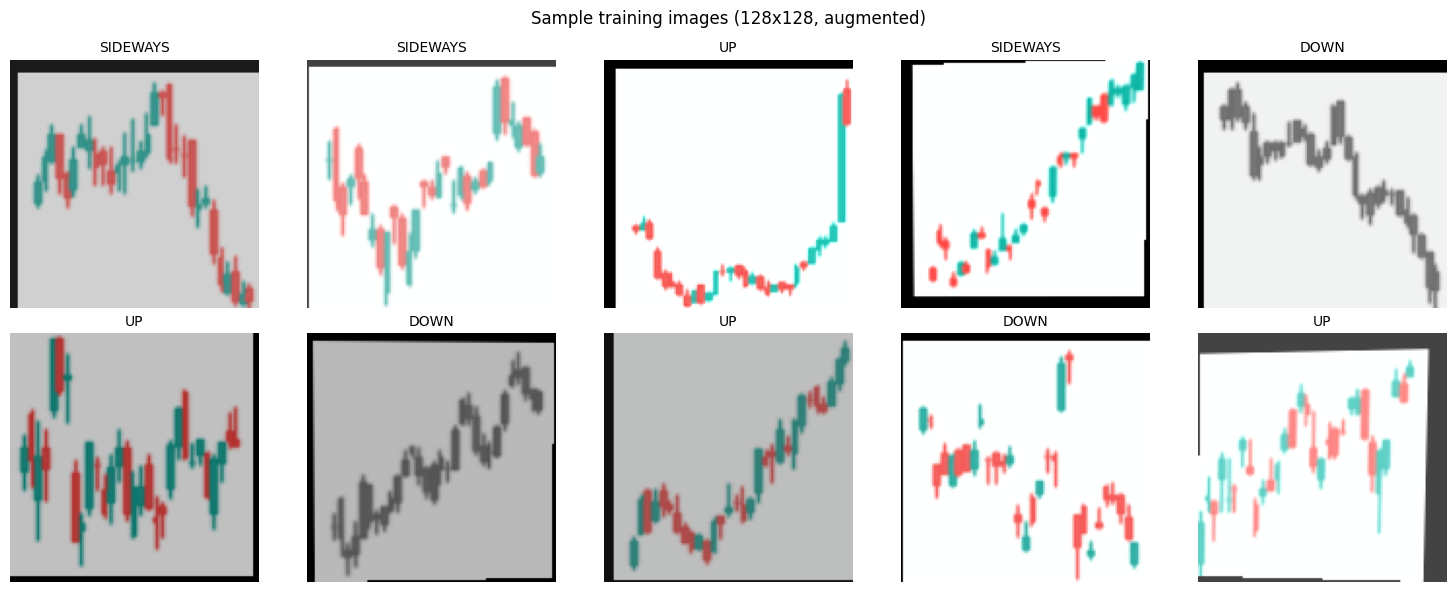

Dataset pipeline ready.


In [ ]:
# ── Transforms ────────────────────────────────────────────────────────────────
# Using 128x128 — matches the resolution images were generated at.
# Augmentation improvements from v3 kept (perspective warp, saturation).
# RandomHorizontalFlip still excluded — flipping reverses time direction.

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=0, translate=(0.07, 0.07)),
    transforms.RandomPerspective(distortion_scale=0.05, p=0.3),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── Load dataset ──────────────────────────────────────────────────────────────
train_dataset = datasets.ImageFolder(IMG_DIR, transform=train_transforms)
eval_dataset  = datasets.ImageFolder(IMG_DIR, transform=eval_transforms)

class_names = train_dataset.classes
total       = len(train_dataset)
print(f'Classes : {class_names}')
print(f'Total   : {total} images')

# ── Train / Val / Test split (70 / 15 / 15) ───────────────────────────────────
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

generator     = torch.Generator().manual_seed(SEED)
all_indices   = torch.randperm(total, generator=generator).tolist()
train_indices = all_indices[:train_size]
val_indices   = all_indices[train_size : train_size + val_size]
test_indices  = all_indices[train_size + val_size:]

train_ds = Subset(train_dataset, train_indices)
val_ds   = Subset(eval_dataset,  val_indices)
test_ds  = Subset(eval_dataset,  test_indices)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

# ── Weighted sampler (fix class imbalance) ────────────────────────────────────
# SIDEWAYS = 59% of data. Sampler alone is sufficient for balancing.
# Dual weighting (sampler + weighted loss) overcorrects and hurts accuracy.
train_labels = [train_dataset.targets[i] for i in train_indices]
class_counts = np.bincount(train_labels)
print(f'\nTrain class counts: {dict(zip(class_names, class_counts))}')

class_weights  = 1.0 / class_counts
sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# ── Sanity check ─────────────────────────────────────────────────────────────
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(std * img + mean, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[labels[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample training images (128x128, augmented)', fontsize=12)
plt.tight_layout()
plt.show()
print('Dataset pipeline ready.')


## Cell 3 — Training Helper (shared by both models)

In [ ]:
def train_model(model, optimizer, scheduler, epochs, model_name,
                cosine_scheduler=False):
    """
    Generic training loop. Saves best checkpoint by val accuracy.

    Args:
        cosine_scheduler: if True, calls scheduler.step() with no args
                          (for CosineAnnealingLR). If False, passes val_loss
                          (for ReduceLROnPlateau).

    Loss: CrossEntropyLoss with label_smoothing=0.1.
    Markets are noisy — a 2.1% move and 1.9% move get opposite labels
    despite being almost identical. Smoothing prevents overconfidence
    on borderline cases. No class weights in loss — sampler handles balancing.
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_acc  = 0.0
    best_wts  = copy.deepcopy(model.state_dict())
    history   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    save_path = os.path.join(MODEL_DIR, f'{model_name}.pth')

    for epoch in range(epochs):
        t0 = time.time()
        current_lr = optimizer.param_groups[0]['lr']

        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        running_loss, running_correct = 0.0, 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            running_loss    += loss.item() * imgs.size(0)
            running_correct += (out.argmax(1) == lbls).sum().item()

        train_loss = running_loss    / len(train_ds)
        train_acc  = running_correct / len(train_ds)

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        val_loss_sum, val_correct = 0.0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out  = model(imgs)
                loss = criterion(out, lbls)
                val_loss_sum += loss.item() * imgs.size(0)
                val_correct  += (out.argmax(1) == lbls).sum().item()

        val_loss = val_loss_sum / len(val_ds)
        val_acc  = val_correct  / len(val_ds)

        # ── Scheduler step ────────────────────────────────────────────────────
        if cosine_scheduler:
            scheduler.step()           # CosineAnnealingLR: no argument
        else:
            scheduler.step(val_loss)   # ReduceLROnPlateau: needs val_loss

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        is_best = val_acc > best_acc
        if is_best:
            best_acc = val_acc
            best_wts = copy.deepcopy(model.state_dict())
            torch.save(best_wts, save_path)

        print(f'Epoch [{epoch+1:02d}/{epochs}]  '
              f'Train loss: {train_loss:.4f}  acc: {train_acc:.4f}  |  '
              f'Val loss: {val_loss:.4f}  acc: {val_acc:.4f}  '
              f'lr: {current_lr:.2e}  [{time.time()-t0:.1f}s]'
              + (' ← best' if is_best else ''))

    model.load_state_dict(best_wts)
    print(f'\nBest val accuracy: {best_acc:.4f}')
    print(f'Saved → {save_path}')
    return model, history


def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], label='Train')
    ax1.plot(epochs, history['val_loss'],   label='Val')
    ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
    ax2.plot(epochs, history['train_acc'], label='Train')
    ax2.plot(epochs, history['val_acc'],   label='Val')
    ax2.axhline(0.333, color='gray',   linestyle=':', label='Random baseline (33%)')
    ax2.axhline(0.590, color='orange', linestyle=':', label='Naive baseline — always SIDEWAYS (59%)')
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

print('Training helper ready.')


Training helper ready.


## Cell 4 — VGG16 (Transfer Learning)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 86.8MB/s]


VGG16 — trainable: 4,260,867 / total: 18,975,555
Phase 1: frozen backbone, training classifier head only

Phase 1 — Training classifier head only...
Epoch [01/15]  Train loss: 1.1136  acc: 0.3489  |  Val loss: 1.1042  acc: 0.3700  lr: 1.00e-03  [24.6s] ← best
Epoch [02/15]  Train loss: 1.0990  acc: 0.3576  |  Val loss: 1.0932  acc: 0.3498  lr: 1.00e-03  [22.5s]
Epoch [03/15]  Train loss: 1.0945  acc: 0.3697  |  Val loss: 1.1030  acc: 0.3485  lr: 1.00e-03  [23.2s]
Epoch [04/15]  Train loss: 1.0902  acc: 0.3871  |  Val loss: 1.0843  acc: 0.4207  lr: 1.00e-03  [21.5s] ← best
Epoch [05/15]  Train loss: 1.0858  acc: 0.3975  |  Val loss: 1.0671  acc: 0.4265  lr: 1.00e-03  [23.3s] ← best
Epoch [06/15]  Train loss: 1.0779  acc: 0.4253  |  Val loss: 1.0700  acc: 0.4545  lr: 1.00e-03  [21.8s] ← best
Epoch [07/15]  Train loss: 1.0743  acc: 0.4235  |  Val loss: 1.0506  acc: 0.4844  lr: 1.00e-03  [23.2s] ← best
Epoch [08/15]  Train loss: 1.0769  acc: 0.4140  |  Val loss: 1.0783  acc: 0.3979  lr: 1.

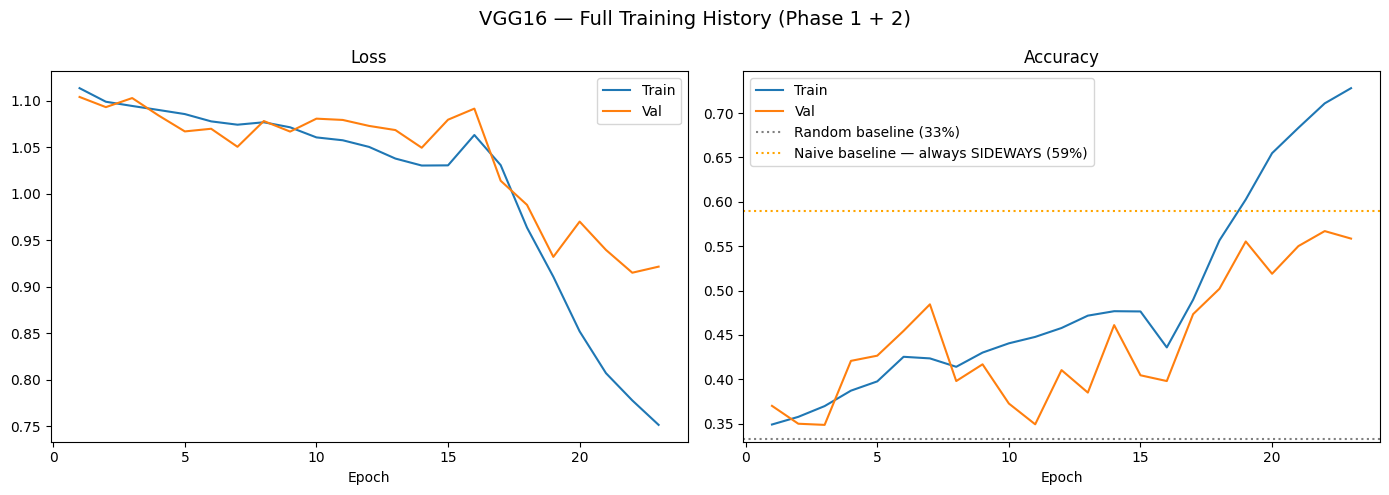

Backed up vgg16.pth to Drive.


In [ ]:
vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Phase 1: freeze everything
for param in vgg.parameters():
    param.requires_grad = False

# Replace VGG16 classifier (originally built for 1000 ImageNet classes)
# VGG16's feature extractor outputs 512*7*7=25088 — but at 128x128 input
# after 5 MaxPool(2,2): 128→64→32→16→8→4, so output is 512*4*4=8192.
# Use AdaptiveAvgPool to fix the spatial size regardless of input resolution.
vgg.avgpool = nn.AdaptiveAvgPool2d((4, 4))   # fix spatial output to 4x4
in_features_vgg = 512 * 4 * 4               # = 8192

vgg.classifier = nn.Sequential(
    nn.Linear(in_features_vgg, 512),
    nn.ReLU(),  # Removed inplace=True
    nn.Dropout(0.5),
    nn.Linear(512, 128),
    nn.ReLU(),  # Removed inplace=True
    nn.Dropout(0.4),
    nn.Linear(128, NUM_CLASSES)
)
vgg = vgg.to(device)

trainable = sum(p.numel() for p in vgg.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in vgg.parameters())
print(f'VGG16 — trainable: {trainable:,} / total: {total_p:,}')
print('Phase 1: frozen backbone, training classifier head only')

vgg_optimizer = optim.Adam(vgg.classifier.parameters(), lr=LR, weight_decay=1e-4)
vgg_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    vgg_optimizer, mode='min', patience=3, factor=0.5
)

print('\nPhase 1 — Training classifier head only...')
vgg, vgg_history = train_model(
    vgg, vgg_optimizer, vgg_scheduler,
    epochs=EPOCHS_RES, model_name='vgg16',
    cosine_scheduler=False
)

# ── Phase 2: Unfreeze last 2 conv blocks only ─────────────────────────────────
# VGG16 features layout:
#   features[0:17]  — blocks 1-3 (low-level: edges, textures)  → KEEP FROZEN
#   features[17:31] — blocks 4-5 (high-level: complex patterns) → UNFREEZE
# Unfreezing only the high-level blocks adapts them to candlestick patterns
# without risking overfit from the low-level layers also updating.
print('\nPhase 2 — Unfreezing last 2 conv blocks (features[17:])...')
for param in vgg.features[17:].parameters():
    param.requires_grad = True
for param in vgg.classifier.parameters():
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in vgg.parameters() if p.requires_grad)
print(f'  Trainable in Phase 2: {trainable_p2:,} / {total_p:,}')

vgg_ft_epochs = 8
vgg_ft_lr     = 5e-5   # lower than ResNet because VGG is more parameter-heavy

vgg_ft_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, vgg.parameters()),
    lr=vgg_ft_lr,
    weight_decay=1e-3
)
vgg_ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    vgg_ft_optimizer, T_max=vgg_ft_epochs, eta_min=1e-6
)

print(f'  Fine-tune LR: {vgg_ft_lr} → 1e-6 over {vgg_ft_epochs} epochs (cosine)')

vgg, vgg_ft_history = train_model(
    vgg, vgg_ft_optimizer, vgg_ft_scheduler,
    epochs=vgg_ft_epochs, model_name='vgg16',
    cosine_scheduler=True
)

full_vgg_history = {k: vgg_history[k] + vgg_ft_history[k] for k in vgg_history}
plot_history(full_vgg_history, 'VGG16 — Full Training History (Phase 1 + 2)')

shutil.copy(f'{MODEL_DIR}/vgg16.pth', f'{DRIVE_DIR}/vgg16.pth')
print('Backed up vgg16.pth to Drive.')

## Cell 5 — ResNet18 (Transfer Learning, Improved)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 133MB/s]


ResNet18 — trainable: 147,971 / total: 11,324,483

Phase 1 — Training FC head only...
Epoch [01/15]  Train loss: 1.1068  acc: 0.3395  |  Val loss: 1.0903  acc: 0.5137  lr: 1.00e-03  [20.0s] ← best
Epoch [02/15]  Train loss: 1.0989  acc: 0.3516  |  Val loss: 1.0861  acc: 0.5358  lr: 1.00e-03  [18.2s] ← best
Epoch [03/15]  Train loss: 1.0988  acc: 0.3578  |  Val loss: 1.1158  acc: 0.1691  lr: 1.00e-03  [19.1s]
Epoch [04/15]  Train loss: 1.0973  acc: 0.3534  |  Val loss: 1.0957  acc: 0.4174  lr: 1.00e-03  [19.1s]
Epoch [05/15]  Train loss: 1.0964  acc: 0.3585  |  Val loss: 1.0978  acc: 0.4090  lr: 1.00e-03  [18.2s]
Epoch [06/15]  Train loss: 1.0960  acc: 0.3622  |  Val loss: 1.1080  acc: 0.3283  lr: 1.00e-03  [18.3s]
Epoch [07/15]  Train loss: 1.0940  acc: 0.3732  |  Val loss: 1.0860  acc: 0.4200  lr: 5.00e-04  [18.8s]
Epoch [08/15]  Train loss: 1.0952  acc: 0.3633  |  Val loss: 1.0768  acc: 0.5098  lr: 5.00e-04  [19.7s]
Epoch [09/15]  Train loss: 1.0934  acc: 0.3774  |  Val loss: 1.0596 

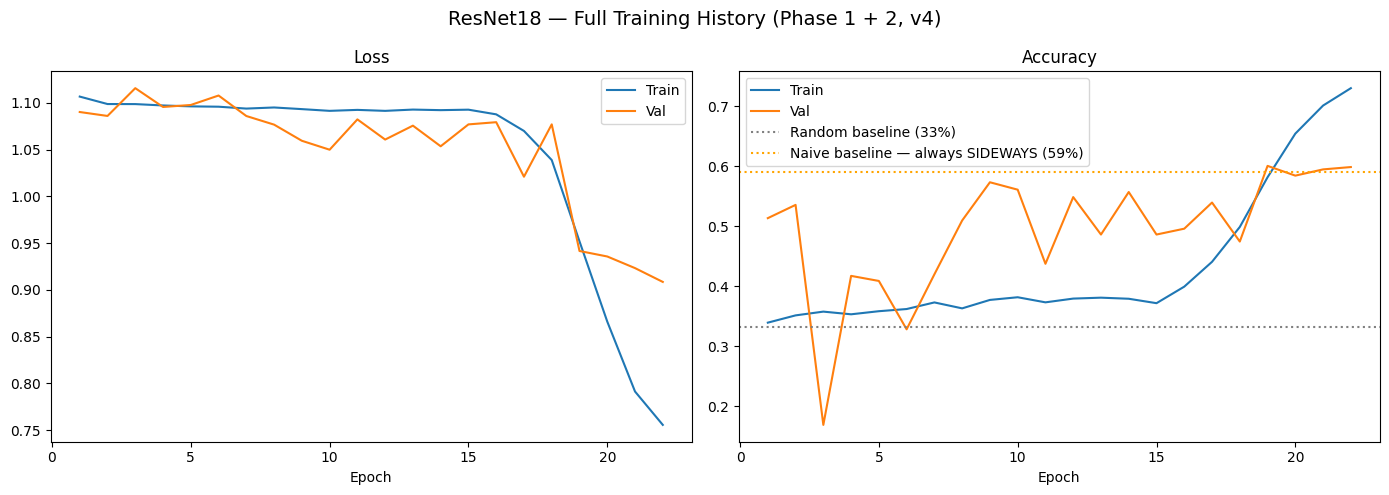

Backed up resnet18.pth to Drive.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# ResNet18 — Improved Training (v4)
#
# Fix vs v3.2: Dropout in FC bottleneck reduced 0.3 → 0.2.
# In v3.2, SIDEWAYS recall dropped from 63% to 58% — the deeper head with
# Dropout(0.3) was over-regularizing the pathway for the majority class.
# Reducing to 0.2 gives the network slightly more capacity for SIDEWAYS
# while keeping DOWN/UP regularization from the 0.4 layer.
#
# Everything else from v3.1/v3.2 kept:
#   - FC head: 512 → 256 → 64 → 3
#   - Phase 2 weight_decay: 1e-3
#   - Phase 2 epochs: 7
#   - Phase 2 CosineAnnealingLR
# ═══════════════════════════════════════════════════════════════════════════

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in resnet.parameters():
    param.requires_grad = False

in_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(256, 64),
    nn.ReLU(inplace=True),
    nn.Dropout(0.2),    # reduced from 0.3 — recovers SIDEWAYS recall
    nn.Linear(64, NUM_CLASSES)
)
resnet = resnet.to(device)

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in resnet.parameters())
print(f'ResNet18 — trainable: {trainable:,} / total: {total_p:,}')

res_optimizer = optim.Adam(resnet.fc.parameters(), lr=LR, weight_decay=1e-4)
res_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    res_optimizer, mode='min', patience=3, factor=0.5
)

print('\nPhase 1 — Training FC head only...')
resnet, res_history = train_model(
    resnet, res_optimizer, res_scheduler,
    epochs=EPOCHS_RES, model_name='resnet18',
    cosine_scheduler=False
)

print('\nPhase 2 — Unfreezing all layers for fine-tuning...')
for param in resnet.parameters():
    param.requires_grad = True

ft_epochs = 7
ft_optimizer = optim.Adam(
    resnet.parameters(), lr=1e-4, weight_decay=1e-3
)
ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    ft_optimizer, T_max=ft_epochs, eta_min=1e-6
)
print(f'  Fine-tune LR: 1e-4 → 1e-6 over {ft_epochs} epochs (cosine)')

resnet, ft_history = train_model(
    resnet, ft_optimizer, ft_scheduler,
    epochs=ft_epochs, model_name='resnet18',
    cosine_scheduler=True
)

full_res_history = {k: res_history[k] + ft_history[k] for k in res_history}
plot_history(full_res_history, 'ResNet18 — Full Training History (Phase 1 + 2, v4)')

shutil.copy(f'{MODEL_DIR}/resnet18.pth', f'{DRIVE_DIR}/resnet18.pth')
print('Backed up resnet18.pth to Drive.')


## Cell 6 — Evaluate Both Models


Models loaded.

  VGG16 — Test Accuracy: 0.5721 (57.21%)
  Naive baseline (always SIDEWAYS): 59.00%
  Random baseline (3 classes):      33.33%
              precision    recall  f1-score   support

        DOWN       0.41      0.67      0.51       244
    SIDEWAYS       0.76      0.55      0.64       986
          UP       0.42      0.57      0.48       310

    accuracy                           0.57      1540
   macro avg       0.53      0.60      0.54      1540
weighted avg       0.63      0.57      0.58      1540


  ResNet18 — Test Accuracy: 0.5961 (59.61%)
  Naive baseline (always SIDEWAYS): 59.00%
  Random baseline (3 classes):      33.33%
              precision    recall  f1-score   support

        DOWN       0.33      0.36      0.35       244
    SIDEWAYS       0.70      0.73      0.71       986
          UP       0.45      0.36      0.40       310

    accuracy                           0.60      1540
   macro avg       0.49      0.48      0.49      1540
weighted avg       

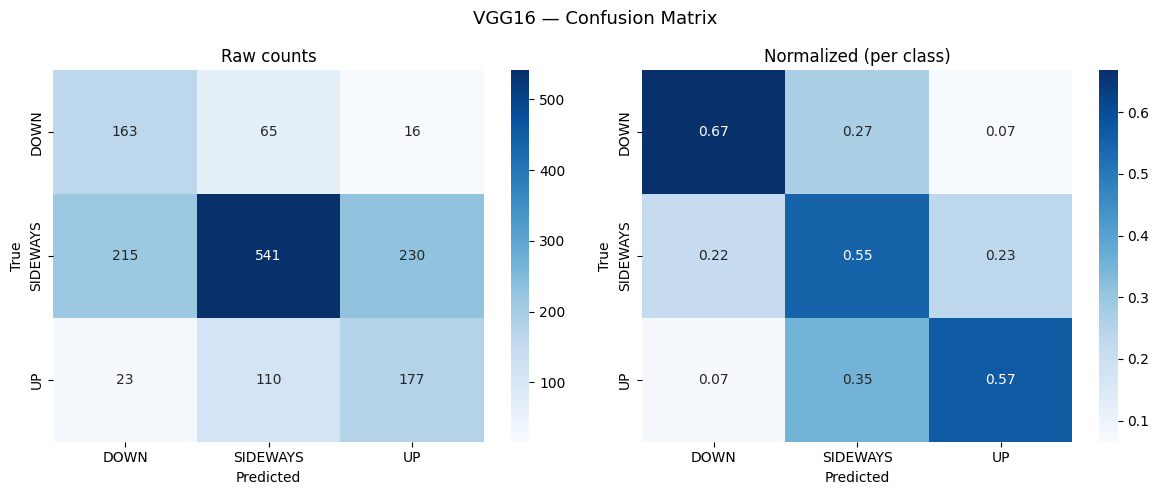

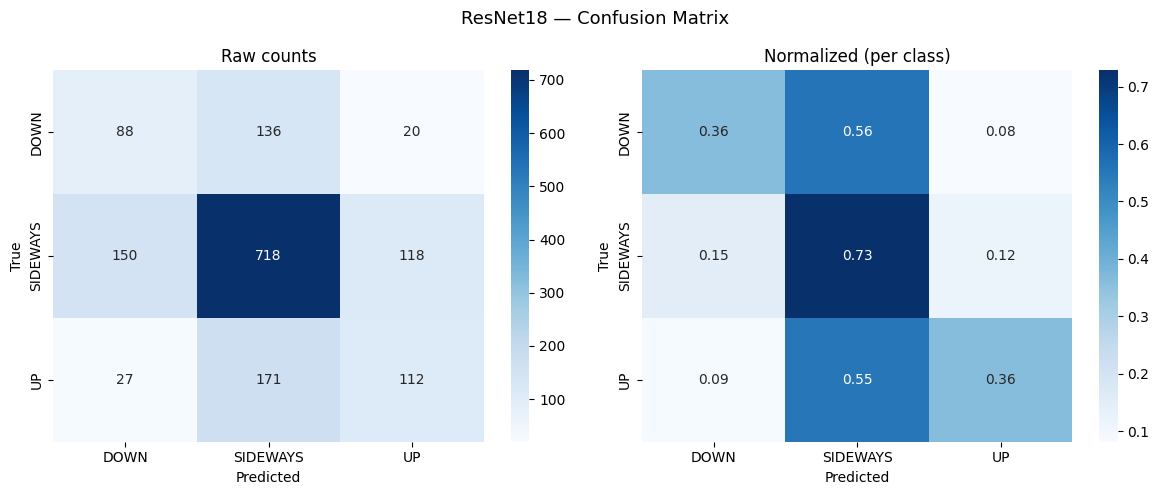


  FINAL COMPARISON
  VGG16      accuracy : 57.21%
  ResNet18   accuracy : 59.61%
  Winner     : ResNet18 by 2.40%
  Naive baseline      : 59.00%


In [ ]:
# ── Load best checkpoints ─────────────────────────────────────────────────────
vgg.load_state_dict(torch.load(f'{MODEL_DIR}/vgg16.pth',       map_location=device))
resnet.load_state_dict(torch.load(f'{MODEL_DIR}/resnet18.pth', map_location=device))
print('Models loaded.')

def evaluate_model(model, loader, model_name):
    model.eval()
    all_preds, all_labels, all_confs = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            out  = model(imgs)
            probs = torch.softmax(out, dim=1)
            confs, preds = probs.max(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())
            all_confs.extend(confs.cpu().numpy())
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f'\n{"="*52}')
    print(f'  {model_name} — Test Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Naive baseline (always SIDEWAYS): 59.00%')
    print(f'  Random baseline (3 classes):      33.33%')
    print(f'{"="*52}')
    print(classification_report(all_labels, all_preds, target_names=class_names,
                                zero_division=0))
    return all_preds, all_labels, all_confs, acc


def plot_confusion_matrix(labels, preds, title):
    cm_raw  = confusion_matrix(labels, preds)
    cm_norm = cm_raw.astype('float') / cm_raw.sum(axis=1)[:, np.newaxis]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(cm_raw,  annot=True, fmt='d',    cmap='Blues', ax=ax1,
                xticklabels=class_names, yticklabels=class_names)
    ax1.set_title('Raw counts'); ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax2,
                xticklabels=class_names, yticklabels=class_names)
    ax2.set_title('Normalized (per class)'); ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


vgg_preds, vgg_labels, vgg_confs, vgg_acc    = evaluate_model(vgg,    test_loader, 'VGG16')
res_preds, res_labels, res_confs, res_acc    = evaluate_model(resnet, test_loader, 'ResNet18')

plot_confusion_matrix(vgg_labels, vgg_preds, 'VGG16 — Confusion Matrix')
plot_confusion_matrix(res_labels, res_preds, 'ResNet18 — Confusion Matrix')

# ── Pick best model ────────────────────────────────────────────────────────────
# FIX v5: best_model and best_name are properly assigned here so all downstream
# cells (Calibration, Per-Ticker, Decision System) can reference them.
if vgg_acc >= res_acc:
    best_model  = vgg
    best_name   = 'VGG16'
    best_preds  = vgg_preds
    best_labels = vgg_labels
    best_confs  = vgg_confs
    best_acc    = vgg_acc
else:
    best_model  = resnet
    best_name   = 'ResNet18'
    best_preds  = res_preds
    best_labels = res_labels
    best_confs  = res_confs
    best_acc    = res_acc

print('\n' + '='*52)
print('  FINAL COMPARISON')
print('='*52)
print(f'  VGG16      accuracy : {vgg_acc*100:.2f}%')
print(f'  ResNet18   accuracy : {res_acc*100:.2f}%')
diff = abs(vgg_acc - res_acc) * 100
print(f'  Winner     : {best_name} by {diff:.2f}%')
print(f'  Naive baseline      : 59.00%')
print('='*52)


## Cell 7 — Grad-CAM Visualization

**Based on Brim & Flann (2022):** Feature map visualization reveals which parts of
the candlestick chart the model focuses on when making predictions.
We run Grad-CAM on the last conv layer of each model.


Generating Grad-CAM for ResNet18...


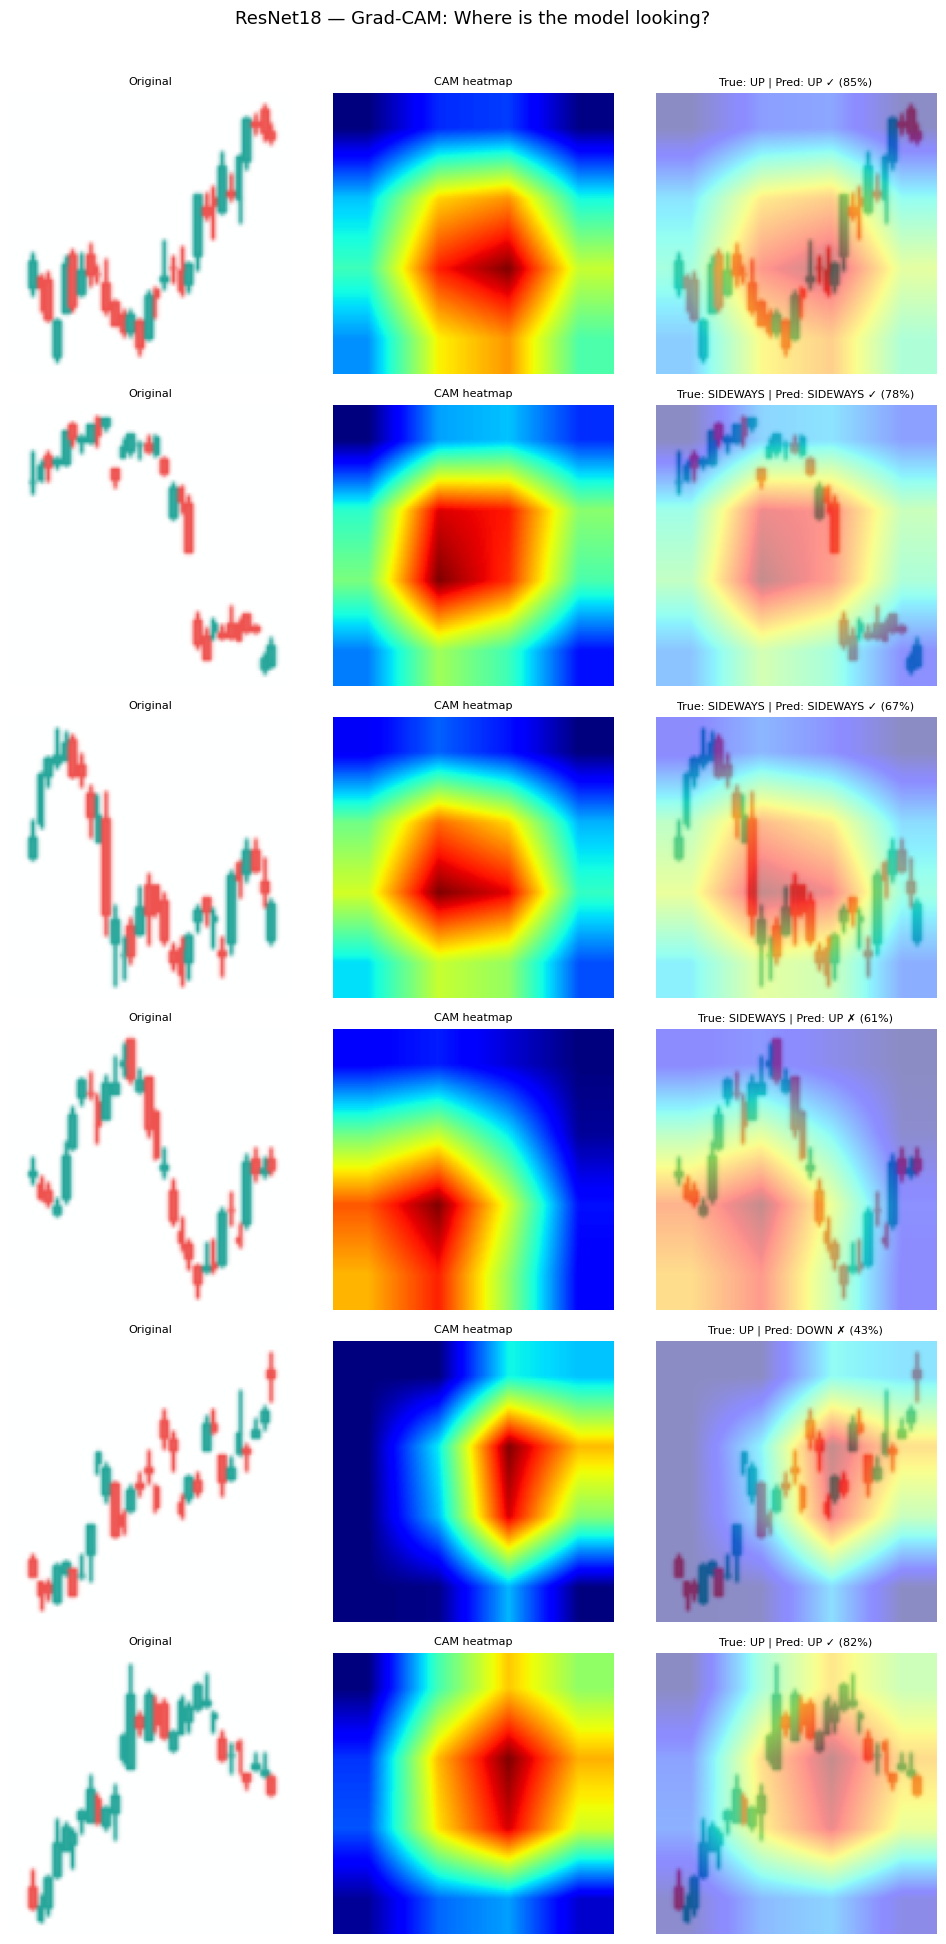

Grad-CAM saved: gradcam_resnet18.png

Generating Grad-CAM for VGG16...


RuntimeError: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace. This view was created inside a custom Function (or because an input was returned as-is) and the autograd logic to handle view+inplace would override the custom backward associated with the custom Function, leading to incorrect gradients. This behavior is forbidden. You can fix this by cloning the output of the custom Function.

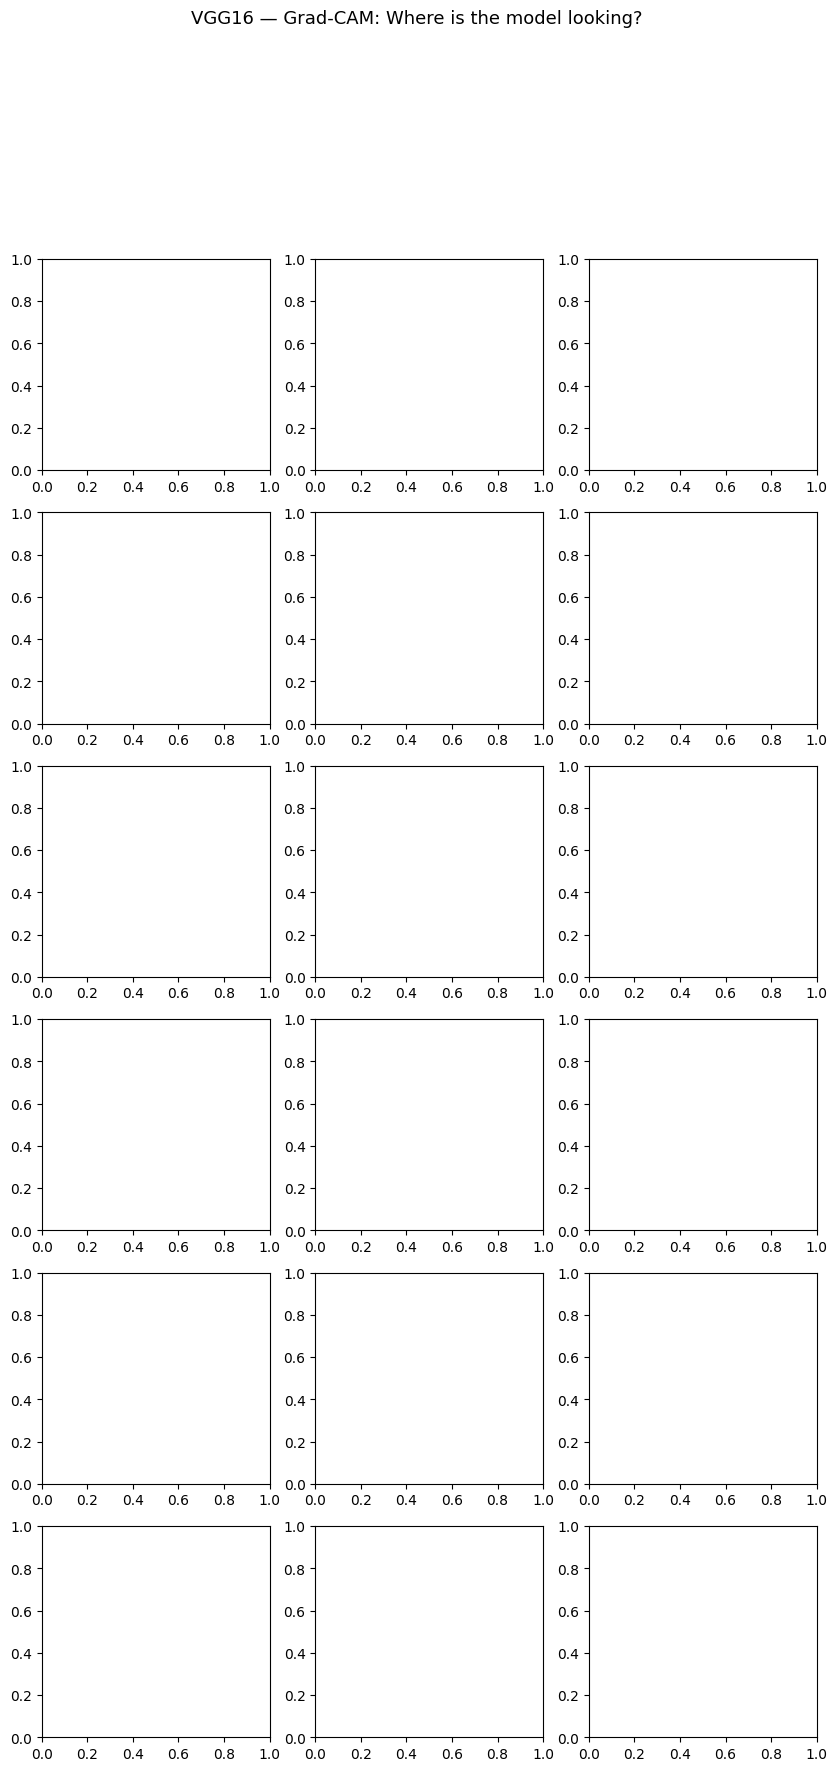

In [ ]:
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, img_tensor, class_idx=None):
        self.model.eval()
        img_tensor = img_tensor.unsqueeze(0).to(device)
        output = self.model(img_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1).squeeze()
        cam     = F.relu(cam).cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        pred_label = class_names[class_idx]
        confidence = torch.softmax(output, dim=1)[0, class_idx].item()
        return cam, pred_label, confidence


def show_gradcam(model, target_layer, model_name, n_samples=6):
    gradcam = GradCAM(model, target_layer)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    imgs, lbls = next(iter(test_loader))
    imgs = imgs[:n_samples]
    lbls = lbls[:n_samples]
    fig, axes = plt.subplots(n_samples, 3, figsize=(10, n_samples * 3.2))
    fig.suptitle(f'{model_name} — Grad-CAM: Where is the model looking?',
                 fontsize=13, y=1.01)
    for i in range(n_samples):
        img_tensor  = imgs[i]
        true_label  = class_names[lbls[i].item()]
        img_display = np.clip(std * img_tensor.permute(1,2,0).numpy() + mean, 0, 1)
        cam, pred_label, conf = gradcam.generate(img_tensor)
        cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        heatmap     = cm.jet(cam_resized)[:, :, :3]
        overlay     = np.clip(0.55 * img_display + 0.45 * heatmap, 0, 1)
        correct     = '✓' if pred_label == true_label else '✗'
        title       = f'True: {true_label} | Pred: {pred_label} {correct} ({conf:.0%})'
        axes[i,0].imshow(img_display); axes[i,0].set_title('Original', fontsize=8)
        axes[i,1].imshow(heatmap);     axes[i,1].set_title('CAM heatmap', fontsize=8)
        axes[i,2].imshow(overlay);     axes[i,2].set_title(title, fontsize=8)
        for ax in axes[i]: ax.axis('off')
    plt.tight_layout()
    fname = f'gradcam_{model_name.lower().replace(" ","_")}.png'
    plt.savefig(f'{MODEL_DIR}/{fname}', dpi=120, bbox_inches='tight')
    plt.show()
    shutil.copy(f'{MODEL_DIR}/{fname}', f'{DRIVE_DIR}/{fname}')
    print(f'Grad-CAM saved: {fname}')


# ── ResNet18: last conv in layer4 ─────────────────────────────────────────────
print('Generating Grad-CAM for ResNet18...')
show_gradcam(resnet, resnet.layer4[1].conv2, 'ResNet18')

# ── VGG16: last conv layer in features (features[28] = Conv2d in block 5) ─────
print('\nGenerating Grad-CAM for VGG16...')
show_gradcam(vgg, vgg.features[28], 'VGG16')


## Cell 8 — Temperature Scaling (Calibration)

The model's raw softmax scores tend to be overconfident — it says 90% sure on predictions it gets wrong. **Temperature scaling** is a lightweight post-processing fix: a single learnable parameter `T` divides the logits before softmax, spreading the distribution when T > 1. We tune `T` on the val set (not test set — no leakage) using LBFGS in seconds.


Calibrating ResNet18 using temperature scaling on val set...
Optimal temperature: 1.472  (T>1 = was overconfident, T<1 = was underconfident)

Evaluating calibrated model...

  ResNet18 (Calibrated) — Test Accuracy: 0.5961 (59.61%)
  Naive baseline (always SIDEWAYS): 59.00%
  Random baseline (3 classes):      33.33%
              precision    recall  f1-score   support

        DOWN       0.33      0.36      0.35       244
    SIDEWAYS       0.70      0.73      0.71       986
          UP       0.45      0.36      0.40       310

    accuracy                           0.60      1540
   macro avg       0.49      0.48      0.49      1540
weighted avg       0.59      0.60      0.59      1540



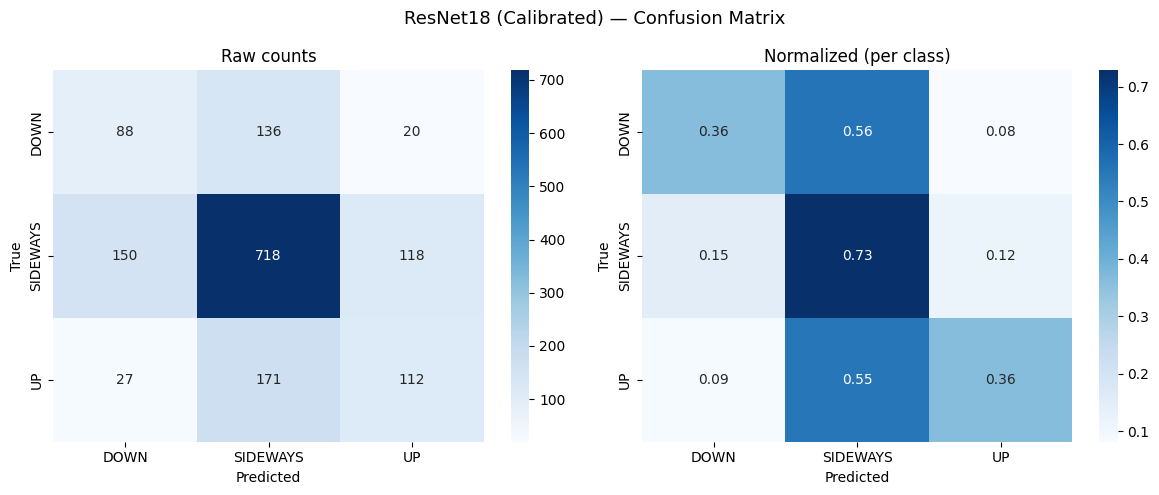


  CALIBRATION COMPARISON
  ResNet18 (Uncalibrated) : 59.61%
  ResNet18 (Calibrated)   : 59.61%
  Naive baseline             : 59.00%


In [ ]:
# ── v5 FIX: Calibration runs HERE (before Decision System) ───────────────────
# In v4, Cell 8 (Decision System) referenced calibrated_model before it was
# defined in Cell 10. This crashed at runtime. Fixed by moving calibration up.

class ModelWithTemperature(nn.Module):
    """Wraps a model and divides logits by a learned temperature T."""
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, x):
        return self.model(x) / self.temperature


def set_temperature(cal_model, loader):
    """Tunes temperature on the validation set using LBFGS."""
    cal_model.eval()
    criterion = nn.NLLLoss()
    optimizer = optim.LBFGS([cal_model.temperature], lr=0.01, max_iter=50)

    with torch.no_grad():
        logits_list, labels_list = [], []
        for inputs, labels in loader:
            logits_list.append(cal_model.model(inputs.to(device)))
            labels_list.append(labels.to(device))
        logits = torch.cat(logits_list)
        labels = torch.cat(labels_list)

    def eval_loss():
        optimizer.zero_grad()
        loss = criterion(F.log_softmax(logits / cal_model.temperature, dim=1), labels)
        loss.backward()
        return loss

    optimizer.step(eval_loss)
    print(f'Optimal temperature: {cal_model.temperature.item():.3f}  '
          f'(T>1 = was overconfident, T<1 = was underconfident)')
    return cal_model


print(f'Calibrating {best_name} using temperature scaling on val set...')
calibrated_model = ModelWithTemperature(best_model).to(device)
calibrated_model = set_temperature(calibrated_model, val_loader)

print(f'\nEvaluating calibrated model...')
cal_preds, cal_labels, cal_confs, cal_acc = evaluate_model(
    calibrated_model, test_loader, f'{best_name} (Calibrated)'
)
plot_confusion_matrix(cal_labels, cal_preds,
                      f'{best_name} (Calibrated) — Confusion Matrix')

print('\n' + '='*52)
print('  CALIBRATION COMPARISON')
print('='*52)
print(f'  {best_name} (Uncalibrated) : {best_acc*100:.2f}%')
print(f'  {best_name} (Calibrated)   : {cal_acc*100:.2f}%')
print(f'  Naive baseline             : 59.00%')
print('='*52)


## Cell 9 — Simulated Decision System


Using ResNet18 (Calibrated) for simulation.
Target 75% not reached — using best accuracy×√coverage.

Optimal confidence threshold : 0.35
  BUY/SELL accuracy           : 39.14%
  BUY/SELL coverage           : 33.2% of all test samples

Total test samples         : 1540
Confidence threshold       : 0.35
Actions taken (BUY/SELL)   : 511 (33.2%)
Held  (low confidence)     : 1029  (66.8%)
Accuracy when acting       : 39.14%
Naive baseline             : 59%
Improvement over naive     : +-19.86%

Action breakdown:
action
HOLD    1029
SELL     262
BUY      249

Per-class accuracy at threshold 0.35:
──────────────────────────────────────────
  UP         : 45.0%  (249 signals)
  DOWN       : 33.6%  (262 signals)
──────────────────────────────────────────


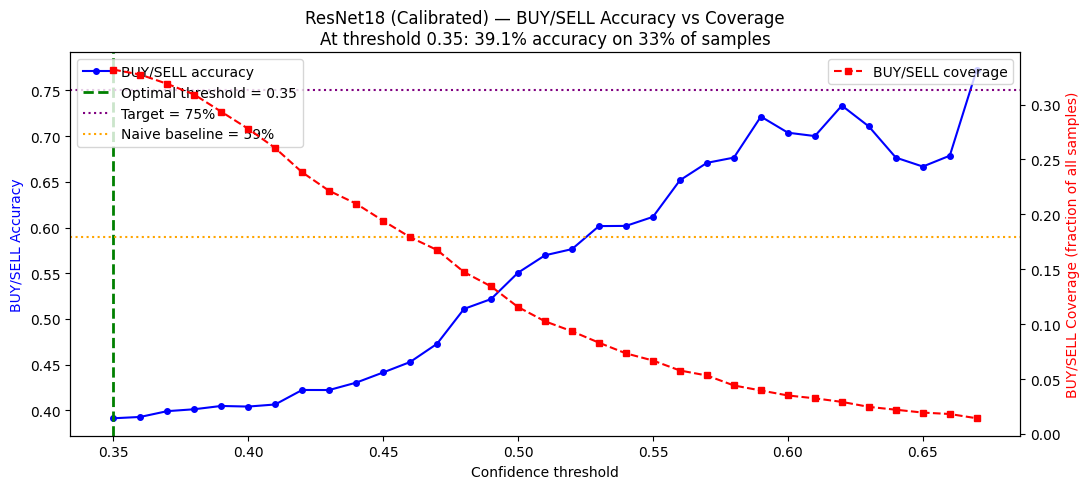

Simulation complete.


In [ ]:
import pandas as pd

# v5: calibrated_model is now defined (Cell 8 ran before this)
sim_name   = f'{best_name} (Calibrated)'
sim_preds  = cal_preds
sim_labels = cal_labels
sim_confs  = cal_confs
print(f'Using {sim_name} for simulation.')

df = pd.DataFrame({
    'pred':    [class_names[p] for p in sim_preds],
    'true':    [class_names[l] for l in sim_labels],
    'conf':     sim_confs,
    'correct': [p == l for p, l in zip(sim_preds, sim_labels)]
})

# ── Threshold sweep — BUY/SELL signals only ───────────────────────────────────
thresholds     = np.arange(0.35, 0.96, 0.01)
acc_at_t, cov_at_t = [], []
naive_baseline = 0.59

for t in thresholds:
    acting_mask = (df['conf'] >= t) & (df['pred'] != 'SIDEWAYS')
    if acting_mask.sum() >= 20:
        acc_at_t.append(df[acting_mask]['correct'].mean())
        cov_at_t.append(acting_mask.mean())
    else:
        acc_at_t.append(np.nan)
        cov_at_t.append(np.nan)

acc_arr = np.array(acc_at_t)
cov_arr = np.array(cov_at_t)
valid   = ~np.isnan(acc_arr)
valid_t, valid_acc, valid_cov = thresholds[valid], acc_arr[valid], cov_arr[valid]

TARGET_ACC   = 0.75
MIN_COVERAGE = 0.15

candidates = (valid_acc >= TARGET_ACC) & (valid_cov >= MIN_COVERAGE)
if candidates.any():
    best_idx = np.where(candidates)[0][0]
    print(f'Target accuracy {TARGET_ACC*100:.0f}% reached on BUY/SELL signals!')
else:
    score    = valid_acc * np.sqrt(valid_cov)
    best_idx = np.argmax(score)
    print(f'Target {TARGET_ACC*100:.0f}% not reached — using best accuracy×√coverage.')

best_t     = valid_t[best_idx]
best_acc_t = valid_acc[best_idx]
best_cov_t = valid_cov[best_idx]

print(f'\nOptimal confidence threshold : {best_t:.2f}')
print(f'  BUY/SELL accuracy           : {best_acc_t*100:.2f}%')
print(f'  BUY/SELL coverage           : {best_cov_t*100:.1f}% of all test samples')

CONFIDENCE_THRESHOLD = float(best_t)

def assign_action(row):
    if row['conf'] >= CONFIDENCE_THRESHOLD and row['pred'] != 'SIDEWAYS':
        return 'BUY' if row['pred'] == 'UP' else 'SELL'
    return 'HOLD'

df['action'] = df.apply(assign_action, axis=1)
acted = df[df['action'] != 'HOLD']
held  = df[df['action'] == 'HOLD']
act_acc = acted['correct'].mean() if len(acted) > 0 else 0

print(f'\nTotal test samples         : {len(df)}')
print(f'Confidence threshold       : {CONFIDENCE_THRESHOLD:.2f}')
print(f'Actions taken (BUY/SELL)   : {len(acted)} ({len(acted)/len(df)*100:.1f}%)')
print(f'Held  (low confidence)     : {len(held)}  ({len(held)/len(df)*100:.1f}%)')
print(f'Accuracy when acting       : {act_acc*100:.2f}%')
print(f'Naive baseline             : {naive_baseline*100:.0f}%')
print(f'Improvement over naive     : +{(act_acc - naive_baseline)*100:.2f}%')
print(f'\nAction breakdown:')
print(df['action'].value_counts().to_string())

print(f'\nPer-class accuracy at threshold {CONFIDENCE_THRESHOLD:.2f}:')
print(f'{"─"*42}')
for cls in ['UP', 'DOWN']:
    mask = acted['pred'] == cls
    if mask.sum() > 0:
        cls_acc = acted[mask]['correct'].mean()
        print(f'  {cls:<10} : {cls_acc*100:.1f}%  ({mask.sum()} signals)')
print(f'{"─"*42}')

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()
ax1.plot(valid_t, valid_acc, 'b-o', markersize=4, label='BUY/SELL accuracy')
ax2.plot(valid_t, valid_cov, 'r--s', markersize=4, label='BUY/SELL coverage')
ax1.axvline(best_t, color='green', linestyle='--', linewidth=2,
            label=f'Optimal threshold = {best_t:.2f}')
ax1.axhline(TARGET_ACC,     color='purple', linestyle=':', linewidth=1.5,
            label=f'Target = {TARGET_ACC*100:.0f}%')
ax1.axhline(naive_baseline, color='orange', linestyle=':', linewidth=1.5,
            label=f'Naive baseline = {naive_baseline*100:.0f}%')
ax1.set_xlabel('Confidence threshold')
ax1.set_ylabel('BUY/SELL Accuracy', color='blue')
ax2.set_ylabel('BUY/SELL Coverage (fraction of all samples)', color='red')
ax1.set_title(
    f'{sim_name} — BUY/SELL Accuracy vs Coverage\n'
    f'At threshold {best_t:.2f}: {best_acc_t*100:.1f}% accuracy '
    f'on {best_cov_t*100:.0f}% of samples'
)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/threshold_plot.png', dpi=120, bbox_inches='tight')
plt.show()
shutil.copy(f'{MODEL_DIR}/threshold_plot.png', f'{DRIVE_DIR}/threshold_plot.png')
print('Simulation complete.')


## Cell 10 — Per-Ticker Analysis



Per-ticker accuracy (ResNet18):
────────────────────────────────────
  AAPL            54.55%  (210/385)
  GLD             68.35%  (270/395)
  RELIANCE.NS     47.12%  (180/382)
  SPY             68.25%  (258/378)
────────────────────────────────────


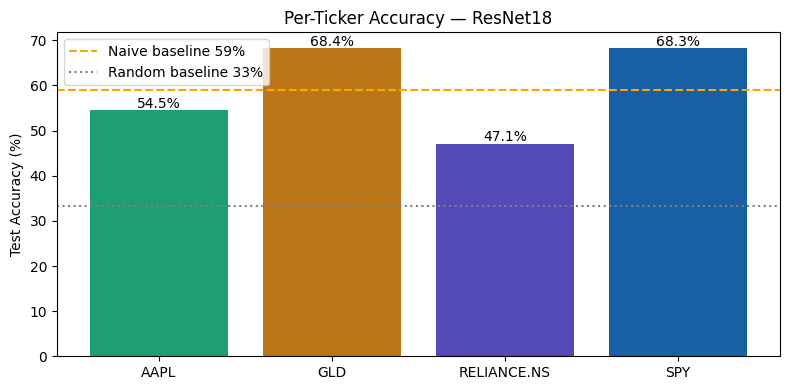

Per-ticker plot saved to Drive.


In [ ]:
# v5 FIX: best_model is now properly set in Cell 6 (evaluate cell)
TICKERS = ['AAPL', 'GLD', 'RELIANCE.NS', 'SPY']
best_model.eval()
ticker_results = {t: {'correct': 0, 'total': 0} for t in TICKERS}

with torch.no_grad():
    for idx in test_indices:
        img_path, label = eval_dataset.samples[idx]
        filename = os.path.basename(img_path)
        ticker   = filename.split('_')[0]
        if 'RELIANCE' in filename:
            ticker = 'RELIANCE.NS'
        if ticker not in ticker_results:
            continue
        img_tensor, _ = eval_dataset[idx]
        out  = best_model(img_tensor.unsqueeze(0).to(device))
        pred = out.argmax(dim=1).item()
        ticker_results[ticker]['total']   += 1
        ticker_results[ticker]['correct'] += int(pred == label)

print(f'\nPer-ticker accuracy ({best_name}):')
print(f'{"─"*36}')
for ticker, r in ticker_results.items():
    if r['total'] > 0:
        acc = r['correct'] / r['total'] * 100
        print(f'  {ticker:<15} {acc:.2f}%  ({r["correct"]}/{r["total"]})')
print(f'{"─"*36}')

tickers_list = [t for t in TICKERS if ticker_results[t]['total'] > 0]
accs = [ticker_results[t]['correct'] / ticker_results[t]['total'] * 100
        for t in tickers_list]

plt.figure(figsize=(8, 4))
bars = plt.bar(tickers_list, accs, color=['#1D9E75', '#BA7517', '#534AB7', '#185FA5'])
plt.axhline(59, color='orange', linestyle='--', label='Naive baseline 59%')
plt.axhline(33.3, color='gray', linestyle=':', label='Random baseline 33%')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', fontsize=10)
plt.ylabel('Test Accuracy (%)')
plt.title(f'Per-Ticker Accuracy — {best_name}')
plt.legend()
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/per_ticker_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()
shutil.copy(f'{MODEL_DIR}/per_ticker_accuracy.png', f'{DRIVE_DIR}/per_ticker_accuracy.png')
print('Per-ticker plot saved to Drive.')


## 🎯 DEMO CELL — Single Image Prediction

**For live demo:** Picks a random test image, shows it, and runs the full prediction pipeline.
Shows: the chart, the model's class probabilities as a bar chart, confidence score, and the trading action.
Run this cell multiple times to cycle through different examples.


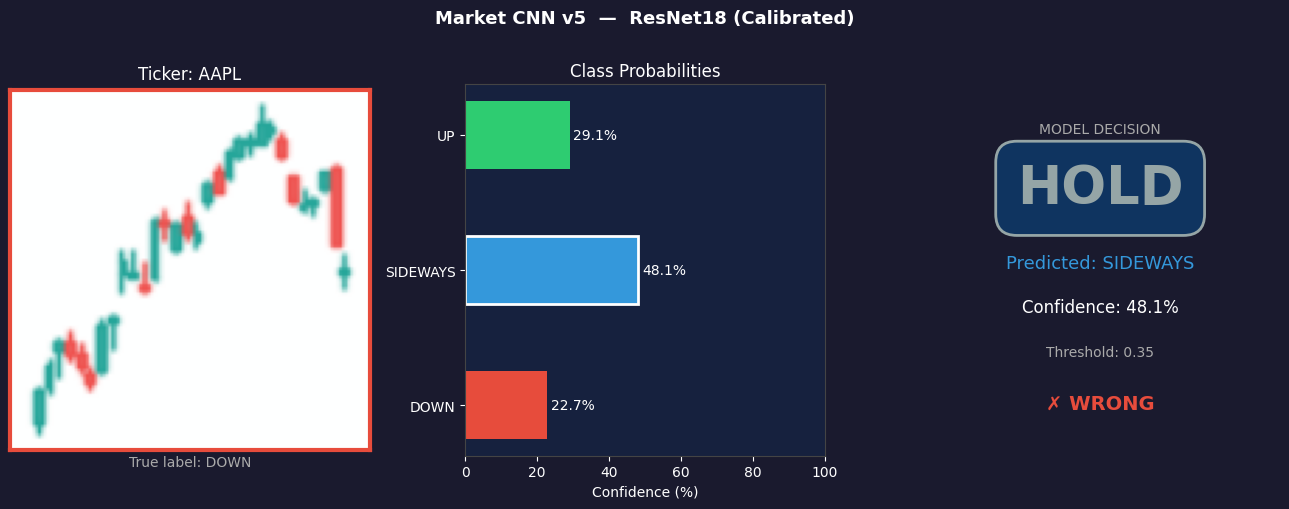


  Ticker      : AAPL
  True label  : DOWN
  Predicted   : SIDEWAYS  (48.1% confidence)
  Action      : HOLD
  Result      : ✗ WRONG

👉  Re-run this cell to get a different random sample.


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 🎯 DEMO: Single-Image Prediction + Trading Signal
# Run this cell repeatedly to see different predictions live.
# ══════════════════════════════════════════════════════════════════════

import random as _random

ACTION_COLORS = {'BUY': '#2ecc71', 'SELL': '#e74c3c', 'HOLD': '#95a5a6'}
CLASS_COLORS  = {'UP': '#2ecc71',  'DOWN': '#e74c3c', 'SIDEWAYS': '#3498db'}

# ── Pick a random test image ──────────────────────────────────────────
demo_idx   = _random.choice(test_indices)
img_path, true_label_idx = eval_dataset.samples[demo_idx]
true_label = class_names[true_label_idx]
ticker     = os.path.basename(img_path).split('_')[0]
if 'RELIANCE' in os.path.basename(img_path):
    ticker = 'RELIANCE.NS'

img_tensor, _ = eval_dataset[demo_idx]

# ── Run calibrated model ──────────────────────────────────────────────
calibrated_model.eval()
with torch.no_grad():
    logits = calibrated_model(img_tensor.unsqueeze(0).to(device))
    probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

pred_idx    = probs.argmax()
pred_label  = class_names[pred_idx]
confidence  = probs[pred_idx]
correct     = pred_label == true_label

# ── Determine trading action ──────────────────────────────────────────
if pred_label == 'UP'   and confidence >= CONFIDENCE_THRESHOLD:  action = 'BUY'
elif pred_label == 'DOWN' and confidence >= CONFIDENCE_THRESHOLD: action = 'SELL'
else:                                                              action = 'HOLD'

# ── Denormalize image for display ─────────────────────────────────────
mean_np = np.array([0.485, 0.456, 0.406])
std_np  = np.array([0.229, 0.224, 0.225])
img_disp = np.clip(std_np * img_tensor.permute(1,2,0).numpy() + mean_np, 0, 1)

# ── Plot ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 5))
fig.patch.set_facecolor('#1a1a2e')

# Panel 1 — Chart image
ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(img_disp)
border_color = '#2ecc71' if correct else '#e74c3c'
for spine in ax1.spines.values():
    spine.set_edgecolor(border_color)
    spine.set_linewidth(3)
ax1.set_title(f'Ticker: {ticker}', color='white', fontsize=12, pad=8)
ax1.set_xlabel(f'True label: {true_label}', color='#aaaaaa', fontsize=10)
ax1.set_xticks([]); ax1.set_yticks([])
ax1.set_facecolor('#1a1a2e')

# Panel 2 — Probability bar chart
ax2 = fig.add_subplot(1, 3, 2)
ax2.set_facecolor('#16213e')
bar_colors = [CLASS_COLORS[c] for c in class_names]
bars = ax2.barh(class_names, probs * 100, color=bar_colors, edgecolor='none', height=0.5)
ax2.set_xlim(0, 100)
ax2.set_xlabel('Confidence (%)', color='white')
ax2.set_title('Class Probabilities', color='white', fontsize=12)
ax2.tick_params(colors='white')
for spine in ax2.spines.values():
    spine.set_edgecolor('#444')
for bar, p in zip(bars, probs):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{p*100:.1f}%', va='center', color='white', fontsize=10)
# Highlight predicted class
pred_bar = bars[pred_idx]
pred_bar.set_edgecolor('white')
pred_bar.set_linewidth(2)

# Panel 3 — Decision summary
ax3 = fig.add_subplot(1, 3, 3)
ax3.set_facecolor('#16213e')
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1)
ax3.axis('off')

action_col = ACTION_COLORS[action]
result_sym = '✓ CORRECT' if correct else '✗ WRONG'
result_col = '#2ecc71' if correct else '#e74c3c'

ax3.text(0.5, 0.88, 'MODEL DECISION',   ha='center', va='center', color='#aaaaaa', fontsize=10)
ax3.text(0.5, 0.72, action,             ha='center', va='center', color=action_col,
         fontsize=38, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#0f3460', edgecolor=action_col, lw=2))
ax3.text(0.5, 0.52, f'Predicted: {pred_label}', ha='center', va='center',
         color=CLASS_COLORS[pred_label], fontsize=13)
ax3.text(0.5, 0.40, f'Confidence: {confidence*100:.1f}%', ha='center', va='center',
         color='white', fontsize=12)
ax3.text(0.5, 0.28, f'Threshold: {CONFIDENCE_THRESHOLD:.2f}', ha='center', va='center',
         color='#aaaaaa', fontsize=10)
ax3.text(0.5, 0.14, result_sym, ha='center', va='center',
         color=result_col, fontsize=14, fontweight='bold')

plt.suptitle(f'Market CNN v5  —  {best_name} (Calibrated)', color='white',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/demo_prediction.png', dpi=130, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print(f'\n{"="*50}')
print(f'  Ticker      : {ticker}')
print(f'  True label  : {true_label}')
print(f'  Predicted   : {pred_label}  ({confidence*100:.1f}% confidence)')
print(f'  Action      : {action}')
print(f'  Result      : {"✓ CORRECT" if correct else "✗ WRONG"}')
print(f'{"="*50}')
print('\n👉  Re-run this cell to get a different random sample.')


## 📊 DEMO — Model Comparison Dashboard

Visual summary of both models for presentations. Shows accuracy, per-class breakdown, and decision system performance side by side.


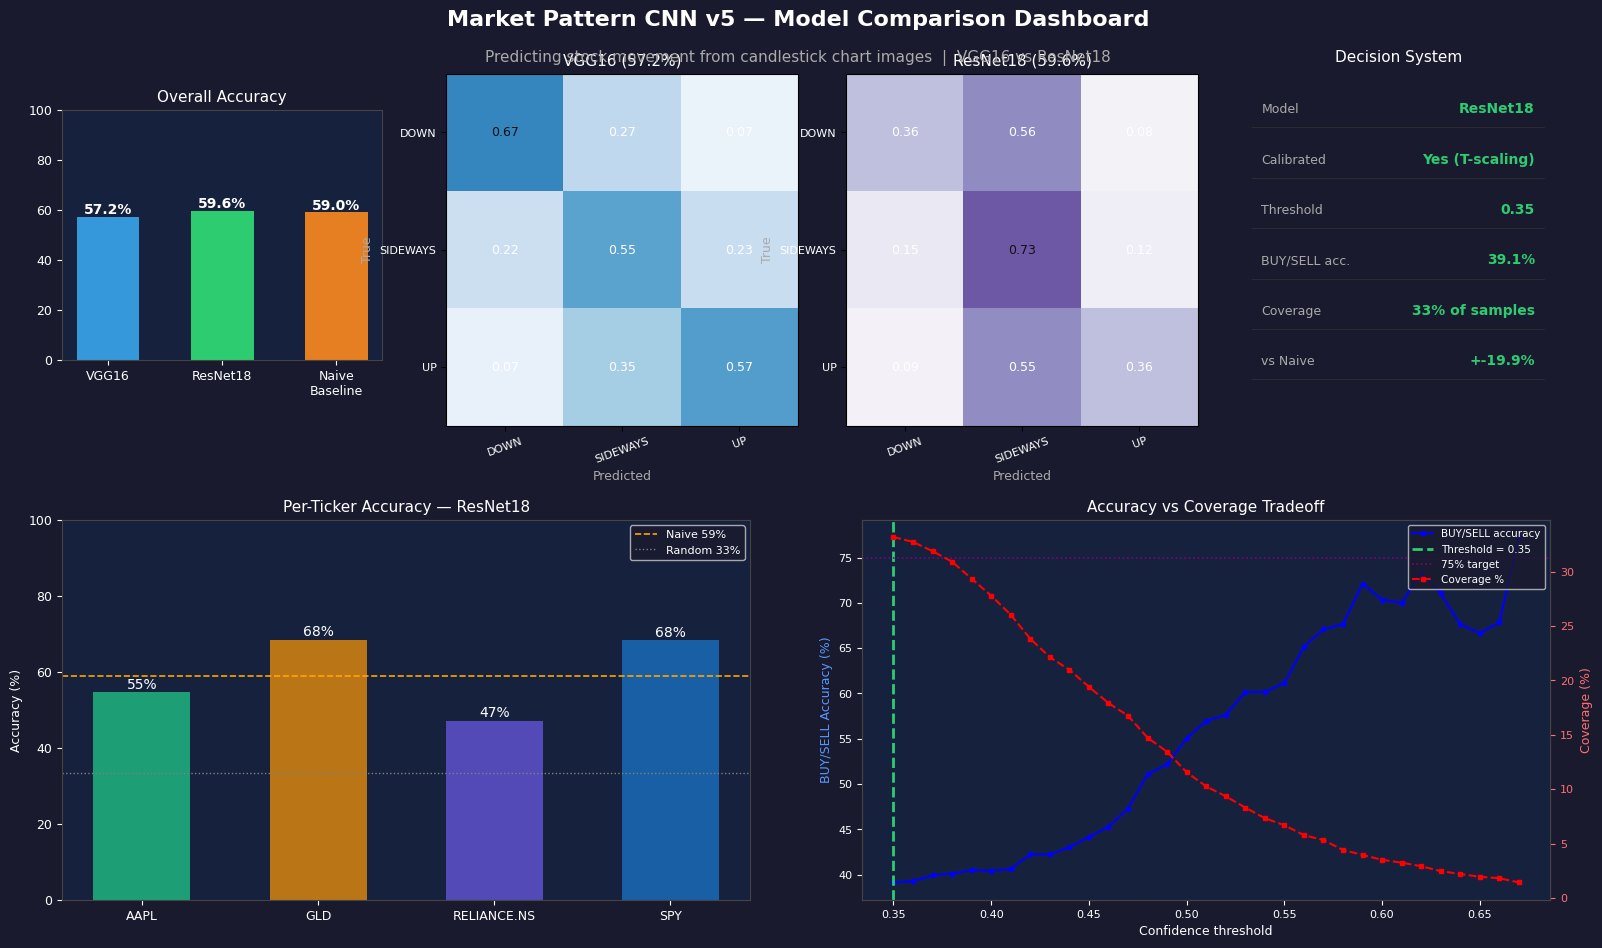

Dashboard saved to Drive.


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 📊 DEMO: Full Model Comparison Dashboard
# Generates a clean, presentation-ready summary figure.
# ══════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#1a1a2e')
BG  = '#16213e'
ACC = '#2ecc71'

# ── Title ─────────────────────────────────────────────────────────────
fig.text(0.5, 0.97, 'Market Pattern CNN v5 — Model Comparison Dashboard',
         ha='center', va='top', color='white', fontsize=16, fontweight='bold')
fig.text(0.5, 0.93, 'Predicting stock movement from candlestick chart images  |  VGG16 vs ResNet18',
         ha='center', va='top', color='#aaaaaa', fontsize=11)

# ── Panel 1: Overall accuracy bar ─────────────────────────────────────
ax1 = fig.add_axes([0.04, 0.62, 0.20, 0.25])
ax1.set_facecolor(BG)
model_names = ['VGG16', 'ResNet18', 'Naive\nBaseline']
accs_pct    = [vgg_acc*100, res_acc*100, 59.0]
colors_bar  = [ACC if a == max(accs_pct[:2]) else '#3498db' for a in accs_pct[:2]] + ['#e67e22']
bars = ax1.bar(model_names, accs_pct, color=colors_bar, width=0.55, edgecolor='none')
ax1.set_ylim(0, 100)
ax1.set_title('Overall Accuracy', color='white', fontsize=11, pad=6)
ax1.tick_params(colors='white', labelsize=9)
for spine in ax1.spines.values(): spine.set_edgecolor('#444')
for bar, a in zip(bars, accs_pct):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{a:.1f}%', ha='center', color='white', fontsize=10, fontweight='bold')
ax1.set_facecolor(BG)

# ── Panel 2: VGG16 confusion matrix ───────────────────────────────────
ax2 = fig.add_axes([0.28, 0.55, 0.22, 0.36])
ax2.set_facecolor(BG)
cm_vgg = confusion_matrix(vgg_labels, vgg_preds)
cm_vgg_n = cm_vgg.astype('float') / cm_vgg.sum(axis=1)[:,np.newaxis]
im = ax2.imshow(cm_vgg_n, cmap='Blues', vmin=0, vmax=1)
ax2.set_xticks(range(NUM_CLASSES)); ax2.set_yticks(range(NUM_CLASSES))
ax2.set_xticklabels(class_names, color='white', fontsize=8, rotation=20)
ax2.set_yticklabels(class_names, color='white', fontsize=8)
ax2.set_xlabel('Predicted', color='#aaa', fontsize=9)
ax2.set_ylabel('True',      color='#aaa', fontsize=9)
ax2.set_title(f'VGG16 ({vgg_acc*100:.1f}%)', color='white', fontsize=11, pad=6)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax2.text(j, i, f'{cm_vgg_n[i,j]:.2f}', ha='center', va='center',
                 color='white' if cm_vgg_n[i,j] < 0.6 else '#111', fontsize=9)

# ── Panel 3: ResNet18 confusion matrix ────────────────────────────────
ax3 = fig.add_axes([0.53, 0.55, 0.22, 0.36])
ax3.set_facecolor(BG)
cm_res = confusion_matrix(res_labels, res_preds)
cm_res_n = cm_res.astype('float') / cm_res.sum(axis=1)[:,np.newaxis]
ax3.imshow(cm_res_n, cmap='Purples', vmin=0, vmax=1)
ax3.set_xticks(range(NUM_CLASSES)); ax3.set_yticks(range(NUM_CLASSES))
ax3.set_xticklabels(class_names, color='white', fontsize=8, rotation=20)
ax3.set_yticklabels(class_names, color='white', fontsize=8)
ax3.set_xlabel('Predicted', color='#aaa', fontsize=9)
ax3.set_ylabel('True',      color='#aaa', fontsize=9)
ax3.set_title(f'ResNet18 ({res_acc*100:.1f}%)', color='white', fontsize=11, pad=6)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax3.text(j, i, f'{cm_res_n[i,j]:.2f}', ha='center', va='center',
                 color='white' if cm_res_n[i,j] < 0.6 else '#111', fontsize=9)

# ── Panel 4: Decision system summary ──────────────────────────────────
ax4 = fig.add_axes([0.78, 0.55, 0.19, 0.36])
ax4.set_facecolor(BG)
ax4.axis('off')
ax4.set_xlim(0,1); ax4.set_ylim(0,1)
ax4.set_title('Decision System', color='white', fontsize=11, pad=6)
items = [
    ('Model',          f'{best_name}'),
    ('Calibrated',     'Yes (T-scaling)'),
    ('Threshold',      f'{CONFIDENCE_THRESHOLD:.2f}'),
    ('BUY/SELL acc.',  f'{best_acc_t*100:.1f}%'),
    ('Coverage',       f'{best_cov_t*100:.0f}% of samples'),
    ('vs Naive',       f'+{(best_acc_t-0.59)*100:.1f}%'),
]
for k, (label, val) in enumerate(items):
    y = 0.88 - k * 0.14
    ax4.text(0.05, y, label,  color='#aaaaaa', fontsize=9)
    ax4.text(0.95, y, val,    color=ACC,        fontsize=10, ha='right', fontweight='bold')
    ax4.axhline(y-0.04, color='#333', linewidth=0.5, xmin=0.02, xmax=0.98)

# ── Panel 5: Per-ticker bar chart ──────────────────────────────────────
ax5 = fig.add_axes([0.04, 0.08, 0.43, 0.38])
ax5.set_facecolor(BG)
if tickers_list:
    bar_cols = ['#1D9E75', '#BA7517', '#534AB7', '#185FA5'][:len(tickers_list)]
    bars5 = ax5.bar(tickers_list, accs, color=bar_cols, width=0.55)
    ax5.axhline(59,   color='orange', linestyle='--', linewidth=1.2, label='Naive 59%')
    ax5.axhline(33.3, color='gray',   linestyle=':',  linewidth=1.0, label='Random 33%')
    ax5.set_ylim(0, 100)
    for bar, a in zip(bars5, accs):
        ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{a:.0f}%', ha='center', color='white', fontsize=10)
ax5.set_title(f'Per-Ticker Accuracy — {best_name}', color='white', fontsize=11, pad=6)
ax5.set_ylabel('Accuracy (%)', color='white', fontsize=9)
ax5.tick_params(colors='white', labelsize=9)
for spine in ax5.spines.values(): spine.set_edgecolor('#444')
ax5.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white')

# ── Panel 6: Threshold curve ──────────────────────────────────────────
ax6 = fig.add_axes([0.54, 0.08, 0.43, 0.38])
ax6.set_facecolor(BG)
ax6_r = ax6.twinx()
ax6.plot(valid_t, valid_acc*100, 'b-o', markersize=3, label='BUY/SELL accuracy')
ax6_r.plot(valid_t, valid_cov*100, 'r--s', markersize=3, label='Coverage %')
ax6.axvline(best_t, color='#2ecc71', linestyle='--', linewidth=2,
            label=f'Threshold = {best_t:.2f}')
ax6.axhline(75, color='purple', linestyle=':', linewidth=1.2, label='75% target')
ax6.set_xlabel('Confidence threshold', color='white', fontsize=9)
ax6.set_ylabel('BUY/SELL Accuracy (%)', color='#5599ff', fontsize=9)
ax6_r.set_ylabel('Coverage (%)', color='#ff7070', fontsize=9)
ax6.set_title('Accuracy vs Coverage Tradeoff', color='white', fontsize=11, pad=6)
ax6.tick_params(colors='white', labelsize=8)
ax6_r.tick_params(colors='#ff7070', labelsize=8)
for spine in ax6.spines.values(): spine.set_edgecolor('#444')
for spine in ax6_r.spines.values(): spine.set_edgecolor('#444')
lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6_r.get_legend_handles_labels()
ax6.legend(lines1+lines2, labels1+labels2, fontsize=7.5,
           facecolor='#1a1a2e', labelcolor='white', loc='upper right')

plt.savefig(f'{MODEL_DIR}/demo_dashboard.png', dpi=130, bbox_inches='tight',
            facecolor=fig.get_facecolor())
shutil.copy(f'{MODEL_DIR}/demo_dashboard.png', f'{DRIVE_DIR}/demo_dashboard.png')
plt.show()
print('Dashboard saved to Drive.')
